# Jane Doe's Capstone Project on Salary Prediction 

[*Example Capstone project for reference only, please do not copy.*]

This is an example of a Capstone project that would achieve a Distinction grade. Please remember that each problem and use case looks different and that there are many ways to perform similar actions in Python, please don't try to force the items in this notebook to fit your use case. Focus on the criteria  and your use case and don't be worried if your steps look different, best of luck!

<font color=green> ✅ Guidance has been provided in the form of green checkpoints, please review your work to ensure you are meeting the criteria.</font>

---


## Project Outline:

1. Introduction
2. The Data
3. Data Exploration and Preparation
4. Model Training and Evaluation
5. Conclusions and Next Steps

---

### 1. Introduction

<font color=green> ✅ **Have you done the following?**<br>Identified an appropriate data question? 
<br> Stated a testable hypothesis and initial expectations? <br>Explained the project's application to the organisation?</font>

Regression analysis is a statistical technique used to establish relationships between a dependent variable and one or more independent variables. By leveraging this approach, we seek to uncover meaningful patterns, trends, and associations within our chosen dataset, and subsequently build a regression model capable of predicting future salaries.

The goal of this project is to develop a regression model that can predict salaries based on age and years of experience with minimal error. The Company could use the model to inform their salary structures and ensure equitable, competitive compensation. This can help in budget planning and in establishing fair pay scales based on experience and age-related factors.

#### The data question, hypotheses and initial expectations
> Can we predict an individual's salary using their age and years of professional experience with minimal error, and what is the relative impact of each of these factors on the salary prediction?

**Null Hypothesis (H₀):** There is no significant relationship between an individual's salary and their age and years of professional experience.

**Alternative Hypothesis (H₁):** There is a significant relationship between an individual's salary and their age and years of professional experience.

It's expected that both age and years of professional experience will have a significant impact on salary. We expect that with more years of experience an individual would accumulate more skills and expertise and therefore have an increasingly higher salary (up to a certain point). It may be that salary plateaus or even decreases after a certain age, reflecting market trends and the ability of the individual to keep their skills up-to-date.

---

### 2. The Data 

<font color=green> ✅ **Have you done the following?**<br>Sourced relevant data?
<br> Fully considered data sharing issues and guidelines?</font>

We have sourced a salaries data set from [Kaggle](https://www.kaggle.com/datasets/rkiattisak/salaly-prediction-for-beginer) to address our data question. When dealing with projects involving personal data like age, years of experience, and especially salary, it's crucial to consider data sharing issues and adhere to relevant guidelines and regulations. 

The columns that exist in this data set are `Age`, `Gender`, `Education Level`, `Job Title`, `Years of Experience` and `Salary`. Personal identifiers such as name, address, contact numbers etc. have already been removed. 

As gender is not relevant to the study's goals, including it might add unnecessary complexity or bias e.g. if the historical data reflects gender-based pay disparities, the model might perpetuate these biases in its predictions.


It is possible that the other columns may act as indirect identifiers, although these may not identify a person on their own, they could do so when combined with other information, e.g. age and job title could quite easily be enough to identify an individual in your workplace. 

Since we will only be considering `Age` and `Years of Experience` to predict `Salary`, we will simply drop the other columns.



In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load in data
df = pd.read_csv('example-only-data/SalaryData.csv')

In [7]:
df.Gender.value_counts()[df.Gender.value_counts() > 190].index

Index(['Male'], dtype='object')

In [9]:
df[df.Gender.isin(df.Gender.value_counts()[df.Gender.value_counts() > 190].index)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
...,...,...,...,...,...,...
365,43.0,Male,Master's,Director of Marketing,18.0,170000.0
367,41.0,Male,Bachelor's,Senior Product Manager,14.0,150000.0
369,33.0,Male,Bachelor's,Junior Business Analyst,4.0,60000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0


In [3]:
# Check head of data
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
# Print the column names
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [5]:
# Drop columns that we will not use
df.drop(columns=['Gender', 'Education Level', 'Job Title'], inplace=True)

df.head()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0


---

### 3. Data Exploration and Preparation

#### i) Exploratory Data Analysis (EDA)

<font color=green> ✅ **Have you done the following?**<br>Examined and discussed core features of the data? 
<br> Used a range of visualization methods and interpreted the results? <br>Used a range of well-chosen statistical methods to analyse data?</font>

<font color=green> ⚠️ Let your data guide your exploration.</font>

Through exploratory data analysis (EDA) we have gained the following initial insights into the dataset:

- We have 375 data points, 2 rows of which are missing. 

- The 3 columns `Age`, `Years of Experience` and `Salary` are all floats, after some analysis we found `Age` and `Salary` should be integers.

- From the `pairplot` visualisation we can see that there is a strong positive correlation between all the variables
    - between `Age` and `Salary` as well as `Years of Experience` and `Salary`, this is a good sign to observe a relationship, it suggests that these independent variables could be a good predictor of the dependent variable, `Salary`, and the relationship appears to be fairly linear which is good for applying linear regression.

    - between the independent variables, `Age` and `Years of Experience`, this is intuitive as each additional year of experience naturally corresponds to an additional year in one's age. However, this is problematic due to a phenomenon known as multicollinearity. This issue can have several adverse effects on the regression model for example it could give unreliable coefficient estimates and standard errors, making it hard to discern the individual impacts of the independent variables on `Salary`.
    
- From the histograms and boxplots we can see that `Age` is more normally distributed that the other variables, `Years of Experience` and `Salary` have a slight positive skew.

- The standard deviation of $48,240 is quite high, indicating that we have a wide variation in salaries. The model we train might struggle to predict salaries well for all cases, especially for those at the extreme ends of the distribution. 

- The min. age in our data is 23 and the max. age is 53, in reality many people start working at 16 and retire at 66 in the UK. Therefore our model may struggle to predict for ages outside of the range of the data.

- We found there are no outliers i.e. values that lie 1.5 times outside of the interquartile range (IQR), however when we break `Salary` down into `Years of Experience` and `Age` we do see outlier salaries at ages 27-35 and at ages 44-51, the most outliers are coming at around 2 and 15-21 years of experience.

#### ii) Data Preprocessing


<font color=green> ✅ **Have you done the following?**<br>Used a range of appropriate data cleaning/preparation methods?
<br> Explained the preparation process and justified decisions based on specific context? <br>Shown an understanding of the implications variable transformations have on the data and the analysis?</font>

<font color=green> ⚠️ You may need to apply some of your preprocessing steps throughout the EDA step, this is recommended. Since outliers or missing values for example might be affecting your results, so as you clean the data you may wish to visualise it again or check the summary statisics again, for example.</font>

During the data preprocessing step we:

- Had missing values where the entire rows of values were missing, therefore, it didn't make sense to fill these with the mean or any other statistic and so we removed these 2 rows completely.
- Fixed the data types, converting `Age` and `Salary` to integers.
- Determined that there is a strong positive correlation between our independent variables `Age` and `Years of Experience`, in order to avoid issues with multicollinearity, we could split these and train two separate models with each variable and compare the results on how well they predict `Salary` so that we can answer our data question.
- We did not find outliers overall, however we did find outliers when looking deeper within certain age groups and certain years of experience, these may have an unwanted affect on the model. Perhaps certain job roles pay significantly better or worse starting salaries depending on education level, perhaps certain job roles have better career progression with increased salaries after many years working etc. We would need to bring back the variables `Job Title` and `Education Level` to look deeper into why these outliers may be appearing and to determine the best method to handle these, this could be an area of future research.

In [6]:
# Check the shape of the data
df.shape

(375, 3)

In [7]:
# Check for missing values
df.isna().sum()

Age                    2
Years of Experience    2
Salary                 2
dtype: int64

In [8]:
# Filter for missing rows
df[df.Age.isna()]

,Age,Years of Experience,Salary
172,NaN,NaN,NaN
260,NaN,NaN,NaN


In [9]:
# Drop missing rows
df = df.dropna()

In [10]:
# Check the shape of the data
df.shape

(373, 3)

In [11]:
# Creating my own function that finds if a column contains floats (so as to not duplicate lines of code)

def return_floats(df, col):
    """
    Finds if a column contains floats.

    Parameters:
    df: The dataframe that contains the column.
    col (string): The column name from the dataframe.

    Returns:
    Returns any floats that were found as a list.
    """
    
    list_floats = []
    list_floats = list(df[(~df[col].isna()) & (df[col] % 1  != 0)][col].unique())
    return(list_floats)

In [12]:
# Check column for floats
return_floats(df,'Age')

[]

In [13]:
# Check column for floats
return_floats(df,'Years of Experience')

[0.5, 1.5]

In [14]:
# Check column for floats
return_floats(df,'Salary')

[]

In [15]:
# Convert 'Age' column to integer type
df.Age = df.Age.astype(int)

In [16]:
# Convert 'Salary' column to integer type
df.Salary = df.Salary.astype(int)

In [17]:
# Check the data types again
df.dtypes

Age                      int64
Years of Experience    float64
Salary                   int64
dtype: object

In [18]:
# Check a sample of the data
df.sample(5)

,Age,Years of Experience,Salary
165,27,1.5,35000
126,37,9.0,95000
155,44,14.0,110000
330,31,3.0,50000
77,32,6.0,100000


In [19]:
# Check summary statistics
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [20]:
# Creating my own function that checks for and returns outliers

def return_outliers(df, col):
    """
    Finds if a column contains outlying values that lie 1.5 times outside of the interquartile range (IQR).

    Parameters:
    df: The dataframe that contains the column.
    col (string): The column name from the dataframe.

    Returns:
    Returns any outliers that were found as a list.
    """
    list_outliers = []
    
    Q1 = df.describe()[col].loc['25%']
    Q3 = df.describe()[col].loc['75%']

    IQR = (Q3 - Q1)
    lower_bound = Q1 - IQR * 1.5
    upper_bound = Q3 + IQR * 1.5

    list_outliers = list(df[df[col] < lower_bound].Salary)
    list_outliers = list_outliers + list(df[df[col] > upper_bound].Salary)

    return(list_outliers)

In [21]:
# Check column for outliers
return_outliers(df, 'Age')

[]

In [22]:
# Check column for outliers
return_outliers(df, 'Years of Experience')

[]

In [23]:
# Check column for outliers
return_outliers(df, 'Salary')

[]

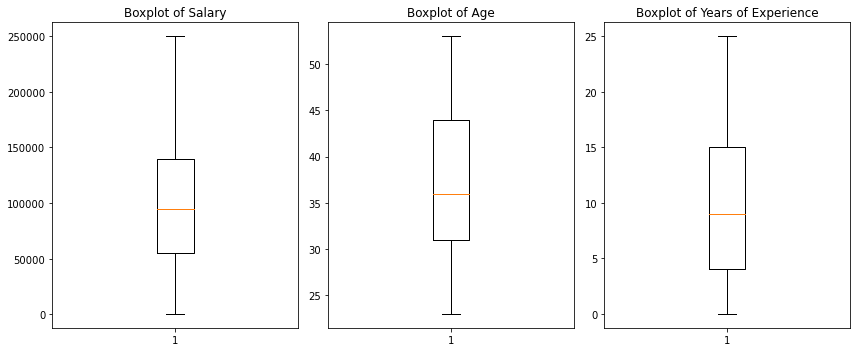

In [24]:
# Plotting boxplots for each variable to see distribution and also check for outliers
fig, axs = plt.subplots(1, 3, figsize=(12, 5))

axs[0].boxplot(df['Salary'])
axs[0].set_title("Boxplot of Salary")

axs[1].boxplot(df['Age'])
axs[1].set_title("Boxplot of Age")

axs[2].boxplot(df['Years of Experience'])
axs[2].set_title("Boxplot of Years of Experience")

plt.tight_layout()
plt.show()

In [25]:
# For bigger images
plt.rcParams['figure.figsize']=(20,10)

Text(0.5, 1.0, 'Boxplot of Salary by Age')

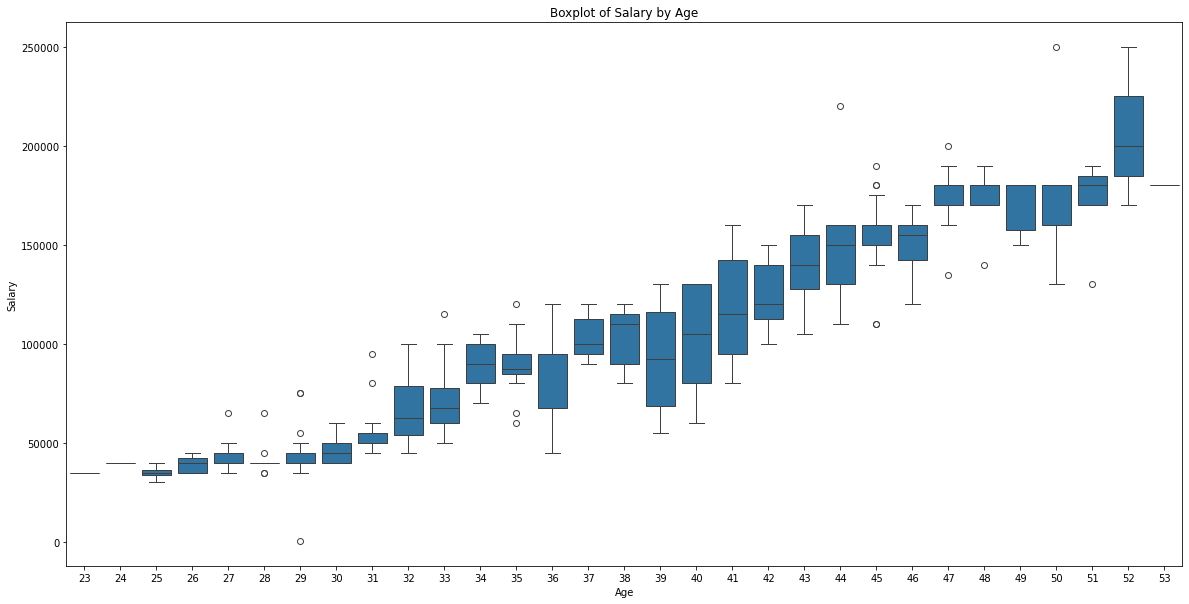

In [26]:
# Plotting a boxplot of salary by age
sns.boxplot(x = 'Age', y='Salary', data=df)

# Adding title
plt.title('Boxplot of Salary by Age')

In [27]:
# Check for outlying salaries at different ages
for i in sorted(df.Age.unique()):
    print(f"{i}: {return_outliers(df[df.Age ==i],'Salary')}")

23: []
24: []
25: []
26: []
27: [65000]
28: [35000, 35000, 65000, 45000]
29: [350, 55000, 75000, 75000]
30: []
31: [80000, 95000]
32: []
33: [115000]
34: []
35: [65000, 60000, 120000]
36: []
37: []
38: []
39: []
40: []
41: []
42: []
43: []
44: [220000]
45: [110000, 110000, 180000, 190000, 180000]
46: []
47: [135000, 200000]
48: [140000]
49: []
50: [250000]
51: [130000]
52: []
53: []


Text(0.5, 1.0, 'Boxplot of Salary by Years of Experience')

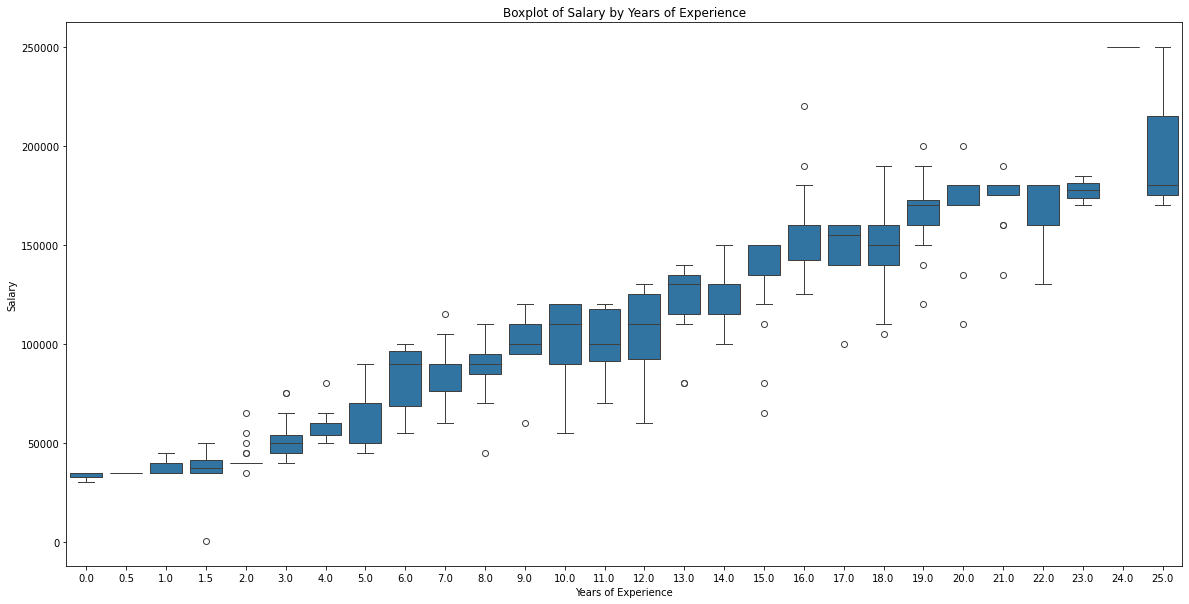

In [28]:
# Plotting a boxplot of salary by years of experience
sns.boxplot(x = 'Years of Experience', y='Salary', data=df)

# Adding title
plt.title('Boxplot of Salary by Years of Experience')

In [29]:
# Check for outlying salaries at different years of experience
for i in sorted(df['Years of Experience'].unique()):
    print(f"{i}: {return_outliers(df[df['Years of Experience'] ==i],'Salary')}")

0.0: []
0.5: []
1.0: []
1.5: [350]
2.0: [35000, 55000, 50000, 45000, 65000, 45000]
3.0: [75000, 75000]
4.0: [80000]
5.0: []
6.0: []
7.0: [115000]
8.0: [45000]
9.0: [60000]
10.0: []
11.0: []
12.0: []
13.0: [80000, 80000]
14.0: []
15.0: [80000, 110000, 65000]
16.0: [190000, 220000]
17.0: [100000]
18.0: [105000]
19.0: [120000, 140000, 200000]
20.0: [110000, 135000, 200000]
21.0: [160000, 135000, 160000, 190000]
22.0: []
23.0: []
24.0: []
25.0: []


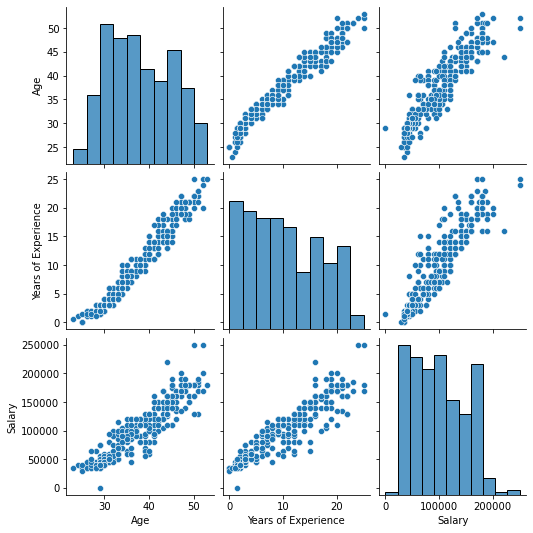

In [30]:
# plotting histograms and scatterplots of variables via. a pairplot
sns.pairplot(df)

---

### 4. Model Training and Evaluation

#### i) Model Training

<font color=green> ✅ **Have you done the following?**<br>Selected appropriate analytical techniques to model the data and justified the selection?
<br>Tailored the model to the specific data and considered a range of tools and techniques?</font>

The steps we applied in model training:

- As we found a linear relationship exists between `Age` and `Salary` as well as `Years of Experience` and `Salary` we will apply a linear regression model, specifically Ordinary Least Squares (OLS). 
- There are no hyperparameters that need tuning in the OLS model that we applied.
- In order to see how well our model performs on unseen data we will use a random 80% of our data for training and 20% for testing. 

- We will set up a baseline model that simply predicts the mean value, so that we have a benchmark level of performance to compare our models to. 

#### ii) Model Evaluation

<font color=green> ✅ **Have you done the following?**<br>Evaluated the model and made improvements where possible?
<br>Discusses model fit criteria and how the improvements affect the fit?</font>

##### Table of Results

|Experiment|Model|Indep. Variables|RMSE|R^2|params|coef|std err|P-value| conf. interval| 
|---|---|---|---|---|---|---|---|---|---|
|0|Baseline| n/a (predicts the mean)|45,606|-0.02|n/a|n/a|n/a|n/a|n/a|
|1|OLS|Age<br>Years of Experience|14,437|0.90|const<br>Age <br> Years of Experience|-18,700<br>1,886 </br>4,854|17,100<br>633<br>682|0.274<br>0.003<br>0.000|[-52200, 14800]<br>[642, 3130]<br>[3513, 6195]|
|2|OLS|Age|15,355|0.88|const<br>Age|-135,000<br>6,294|5,215<br>137|0.000<br>0.000|[-145000, -125000]<br>[6025, 6563]|
|3|OLS|Years of Experience|14,573|0.90|const<br>Years of Experience|31,920<br>6,845|1,678<br>140|0.000<br>0.000|[28600, 35200]<br>[6569, 7120]|

1. Summary of our baseline model that predicts the mean for all new data points
    - Each prediction is the mean of the training set (101,964 USD), this seems quite unreasonable considering the standard deviation of salaries as we found during EDA is 48,240 USD. The standard deviation is almost half the size of the mean. This is a relatively large standard deviation, indicating a wide variation in salaries.
    - The RMSE of 45,606 is very large in the context of salaries. It means that, on average, the predictions deviate from the actual salary values by about 45,606 USD. 
    - The R squared value of -0.02 suggests the model explains 0% of the variability of the data, this model is not good at predicting salaries.
    

2. Summary of our OLS model trained with `Age` and `Years of Experience`
    - The RMSE of 14,437 USD is much lower than that of the baseline model 45,606 USD. Therefore we can say it is worth applying a more complex model than simply using the mean to predict future values.
    - R squared suggests that 90% of the variance in the data could be explained by the model, this is a decent result.
    - The coefficients suggest that salary increases by 1,886 USD for each 1 year increase in age (keeping years of experience constant) and that salary increases by 4,854 USD for an additional year of experience (keeping age constant), this does not seem unreasonable.
    - When testing some edge cases: 
       - Predicting for age 16 (the min. working age in the UK) with 0 years of experince we get £9,017 (after converting to GBP), at the current min. wage in the UK an annual salary pa working full time is £10,433 - so the prediction is a bit low but not too far off.
       - Predicting for someone at the other extreme, e.g. 96 years old with 50 years of experience, we get 405,031 USD. Would someone of this age be actively employed in roles commanding such high salaries? It seems unreasonable.
       - The min. age in our data is 23 and the max. age is 53, in reality many people start working at 16 and retire at 66 in the UK. Therefore our model is missing crucial information of individuals at younger and older ages. We have used a linear model which appears to work well for individuals in the early and mid-stages of a career but perhaps the relationship between age and salary is not strictly linear throughout one's entire working life. We would need to collect more data from younger and older ages to determine this.
    - The constant has a p-value > 0.05 and therefore is not statistically significantly different from 0 when all independent variables are 0, however having the the independent variable `Age` as 0 is not meaningful in this context, therefore we are more interested in the significance of the slope coefficients.
    - The p-value of the slope coefficients, `Age` and `Years of Experience` are both < 0.05 and therefore indicates that there is strong evidence against the null hypothesis, in favor of the alternative hypothesis that there is a significant relationship between an individual's salary and their age and years of professional experience. However, we have large standard errors and wide confidence intervals.
    - The large standard errors and wide confidence intervals suggest that there is considerable variability in the coefficient estimates. We had found during EDA that the independent variables are highly correlated with each other (multicollinearity), which appears to be inflating the standard errors. It is difficult to tease apart the individual effects of correlated variables and so we will train individual OLS models for `Age` and `Years of Experience` so that we can get a clearer view of their effect on `Salary`.


3. Summary of our OLS model trained with `Age`
    - R squared suggests that 88% of the variance in the data could be explained by the model, this is a decent result.
    - The p-values are all less than 0.05, this suggests that the corresponding coefficients are statistically significant, meaning there is strong evidence against the null hypothesis that there is no significant relationship between an individual's salary and their age.
    - We have a smaller confidence interval and standard error with this model's coefficient for age, we can be 95% confident that the true value of the age coefficient lies between 6,025 - 6,563 USD, the standard error is also much smaller.
    - The RMSE of $15,355 isn't as good as the previous model trained with both `Age` and `Years of Experience`.
    - Predicting for age 16 we get -34,316 USD which is an impossible salary value and predicting for age 96 we get 469,216 USD, these are worse predictions for our edge cases than what was got with the previous model.
    
    
4. Summary of our OLS model trained with `Years of Experience`
    - Referring to the R squared and RMSE, this model performs a bit better than the model trained with just `Age` and performs just as well as the model trained with both `Age` and `Years of Experience` i.e. `Age` did not contribute additional significant explanatory power to our model.
    - The confidence intervals for the coefficients are the best overall.
    - A model with fewer predictors is simpler and less prone to overfitting. Occam's razor suggests choosing the simpler model.
    - Therefore, based on all of our points above, we will conclude that this is our best performing model overall.
    
    
    
One of the key assumptions of OLS regression is that the residuals are normally distributed - this assumption holds for all our OLS models (see histograms of residuals), this supports the use of OLS as an appropriate modeling approach for this data.

##### Setting up reusable functions for model training and evaluation

In [31]:
def train_model(df,dep_var,indep_var):
    """
    Applies a train-test-split and trains an OLS model

    Parameters:
    df: The dataframe that contains the dependent and independent variables.
    dep_var: The dependent variable.
    indep_var (List): The independent variables.

    Returns:
    The trained model and X_train, X_test, y_train, y_test.
    """

    # Independent variable
    X = df[indep_var] 
    
    # Add a constant to the independent variable
    X = sm.add_constant(X)

    # Dependent variable
    y = df[dep_var]

    # Splitting the dataset into the Training set and Test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

    # Fit the linear regression model
    model = sm.OLS(y, X).fit()
    
    # Prints the model summary
    print(model.summary())
    
    # Returns the trained model and X_train, X_test, y_train, y_test
    return(model, X_train, X_test, y_train, y_test)

In [32]:
def eval_model(model, X_test, y_test):
    """
    Evaluates the model's performance on a test set.

    Parameters:
    model: The trained regression model.
    X_test: A dataframe of the independent variables in the test set.
    y_test: A series of the dependent variable test set.

    Returns:
    Prints the RMSE and R squared scores.
    """

    # Predicting the Test set results
    y_pred = model.predict(X_test)

    # Evaluates the Model and prints the result
    print('Root Mean squared error (RMSE): %.2f' % np.sqrt(mean_squared_error(y_test, y_pred)))
    print('Coefficient of determination (R^2): %.2f' % r2_score(y_test, y_pred))

In [33]:
def check_residuals(model): 
    """
    Prints a histogram of a regression model's residuals during training.

    Parameters:
    model: The trained regression model.

    Returns:
    A histogram of the residuals.
    """

    # Get the residuals
    residuals = model.resid

    # Histogram of the Residuals
    plt.hist(residuals, bins=30, edgecolor='k')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title('Histogram of Residuals')
    plt.show()

#### Using `Age` and `Years of Experience` to predict salaries

In [34]:
# Apply a train-test-split and train an OLS model
model_1, X_train_1, X_test_1, y_train_1, y_test_1 = train_model(df, 'Salary', ['Age', 'Years of Experience'])

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     1224.
Date:                Fri, 26 Jan 2024   Prob (F-statistic):          7.75e-164
Time:                        10:20:06   Log-Likelihood:                -4172.6
No. Observations:                 373   AIC:                             8351.
Df Residuals:                     370   BIC:                             8363.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -1.87e+04   1

In [35]:
# Evaluate the model's performance on the test set
eval_model(model_1,X_test_1,y_test_1)

Root Mean squared error (RMSE): 14437.28
Coefficient of determination (R^2): 0.90


In [36]:
# Making a prediction for new data points (not in dataset)
new_data = pd.DataFrame({'Age': [16,96], 'Years of Experience':[0,50]})

# Add a constant to the test set
new_data = sm.add_constant(new_data)

# Make predictions
predicted_salary = model_1.predict(new_data)
predicted_salary

0     11472.859728
1    405031.361669
dtype: float64

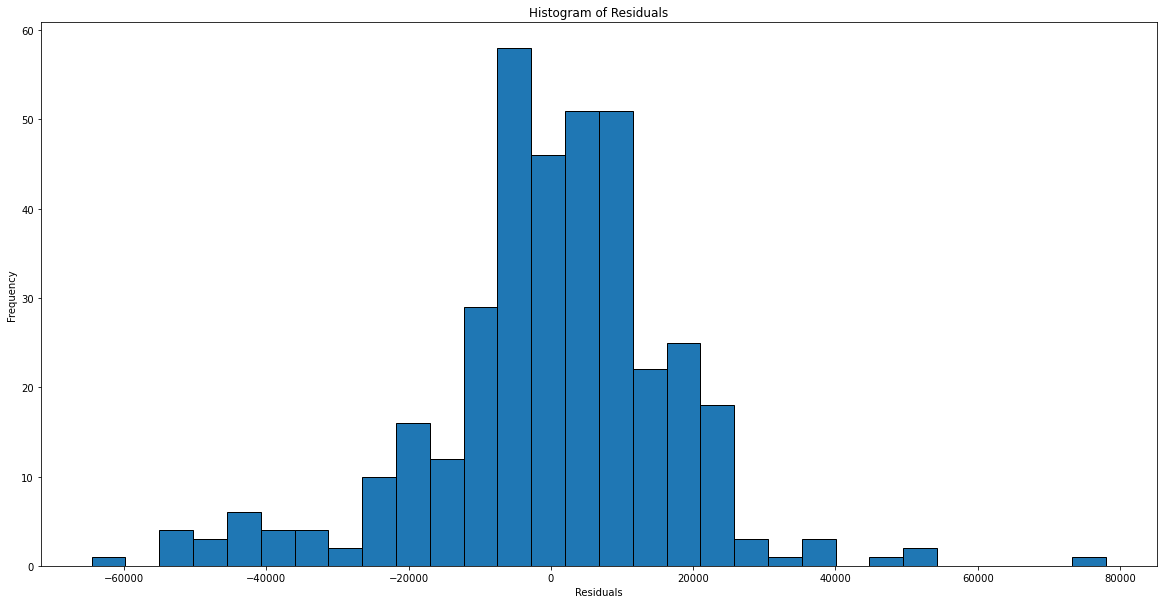

In [37]:
# Print a histogram of the regression model's residuals during training
check_residuals(model_1)

#### Using a baseline model to predict salaries

In [38]:
# Predicting salaries using the average of the training set
y_base_pred = np.array([y_train_1.mean()]*len(y_test_1))

In [39]:
# Evaluate the Model
print('Root Mean squared error (RMSE): %.2f' % np.sqrt(mean_squared_error(y_test_1, y_base_pred)))
print('Coefficient of determination (R^2): %.2f' % r2_score(y_test_1, y_base_pred))

Root Mean squared error (RMSE): 45605.98
Coefficient of determination (R^2): -0.02


#### Using `Age` to predict salaries

In [40]:
# Apply a train-test-split and train an OLS model
model_2, X_train_2, X_test_2, y_train_2, y_test_2 = train_model(df, 'Salary', ['Age'])

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.850
Method:                 Least Squares   F-statistic:                     2114.
Date:                Fri, 26 Jan 2024   Prob (F-statistic):          2.75e-155
Time:                        10:20:06   Log-Likelihood:                -4196.5
No. Observations:                 373   AIC:                             8397.
Df Residuals:                     371   BIC:                             8405.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.35e+05   5214.505    -25.893      0.0

In [41]:
# Evaluate the model's performance on the test set
eval_model(model_2,X_test_2,y_test_2)

Root Mean squared error (RMSE): 15354.95
Coefficient of determination (R^2): 0.88


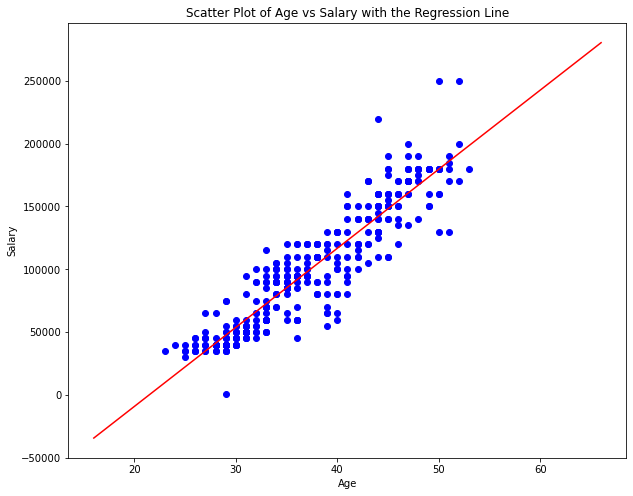

In [42]:
# Setting up subplots
fig, axs = plt.subplots(figsize=(10, 8))

# Plotting age against salary
plt.scatter(df['Age'], df['Salary'], color='blue', label='Data Points');

# Making a dataframe of ages from 16-66 to make predictions for
age_range = list(np.arange(16, 67))
df_2 = pd.DataFrame({'Age': age_range}, index=list(np.arange(0,len(age_range))))

# Add a constant to the dataframe
df_2 = sm.add_constant(df_2)

# Making predictions
predicted_salaries = model_2.predict(df_2)

# Plotting the regression line
plt.plot(list(df_2.Age), list(predicted_salaries), color='red', label='Regression Line');

# Adding a title
plt.title("Scatter Plot of Age vs Salary with the Regression Line");

# Adding labels for X and Y axes
plt.xlabel("Age");
plt.ylabel("Salary");

In [43]:
# Making a prediction for new data points (not in dataset)
new_data = pd.DataFrame({'Age': [16,96]})

# Add a constant to the test set
new_data = sm.add_constant(new_data)

# Make predictions
predicted_salary = model_2.predict(new_data)
predicted_salary

0    -34315.548713
1    469212.594092
dtype: float64

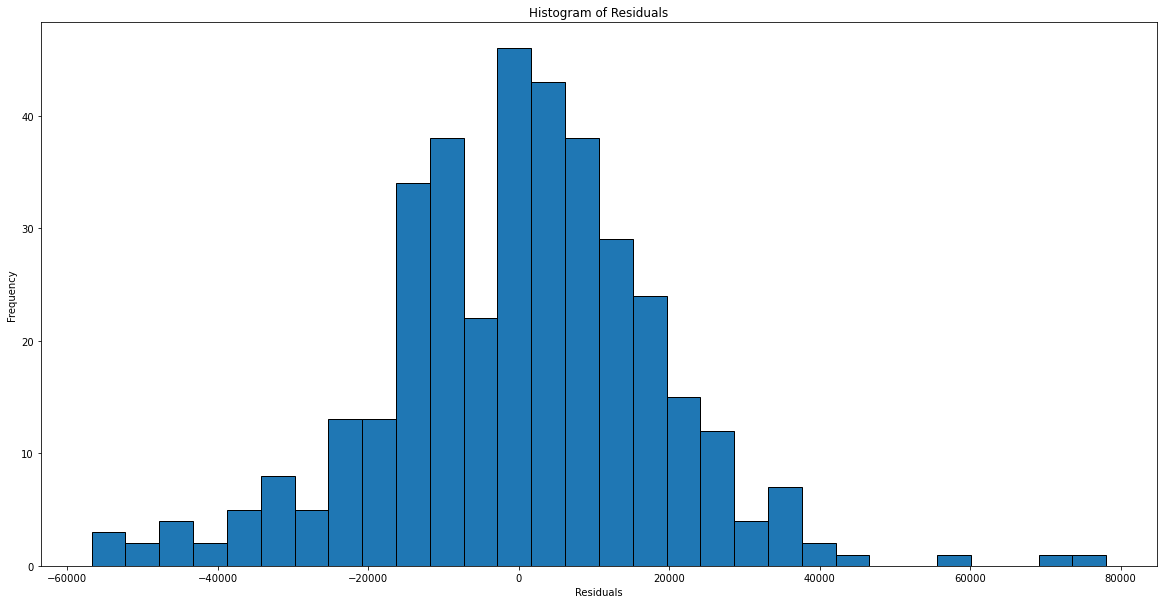

In [44]:
# Print a histogram of the regression model's residuals during training
check_residuals(model_2)

#### Using `Years of Experience` to predict salaries 

In [45]:
# Apply a train-test-split and train an OLS model
model_3, X_train_3, X_test_3, y_train_3, y_test_3  = train_model(df, 'Salary', ['Years of Experience'])

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     2388.
Date:                Fri, 26 Jan 2024   Prob (F-statistic):          1.02e-163
Time:                        10:20:06   Log-Likelihood:                -4177.0
No. Observations:                 373   AIC:                             8358.
Df Residuals:                     371   BIC:                             8366.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3.192e+04   1

In [46]:
# Evaluate the model's performance on the test set
eval_model(model_3,X_test_3,y_test_3)

Root Mean squared error (RMSE): 14573.39
Coefficient of determination (R^2): 0.90


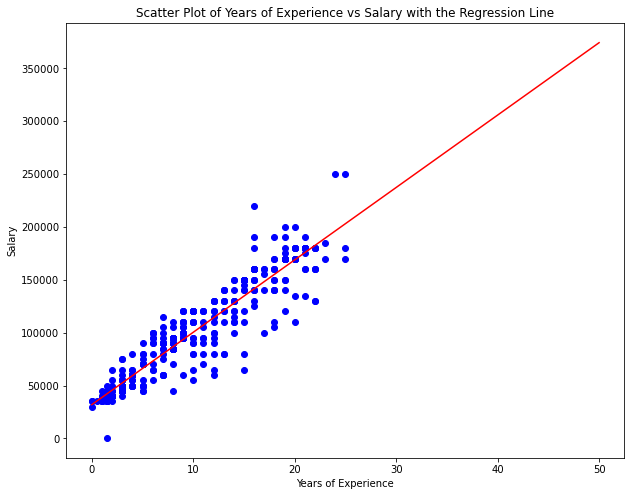

In [47]:
# Setting up subplots
fig, axs = plt.subplots(figsize=(10, 8))

# Plotting years of experience against salary
plt.scatter(df['Years of Experience'], df['Salary'], color='blue', label='Data Points');

# Making a dataframe of years of experience from 0-50 to make predictions for
yoe_range = list(np.arange(0, 51))
df_3 = pd.DataFrame({'Years of Experience': yoe_range}, index=list(np.arange(0,len(yoe_range))))

# Add a constant to the dataframe
df_3 = sm.add_constant(df_3)

# Making predictions
predicted_salaries = model_3.predict(df_3)

# Plotting the regression line
plt.plot(list(df_3['Years of Experience']), list(predicted_salaries), color='red', label='Regression Line');

# Adding a title
plt.title("Scatter Plot of Years of Experience vs Salary with the Regression Line");

# Adding labels for X and Y axes
plt.xlabel("Years of Experience");
plt.ylabel("Salary");

In [48]:
# Making a prediction for new data points (not in dataset)
new_data = pd.DataFrame({'Years of Experience': [0,50]})

# Add a constant to the test set
new_data = sm.add_constant(new_data)

# Make predictions
predicted_salary = model_3.predict(new_data)
predicted_salary

0     31921.216917
1    374146.742641
dtype: float64

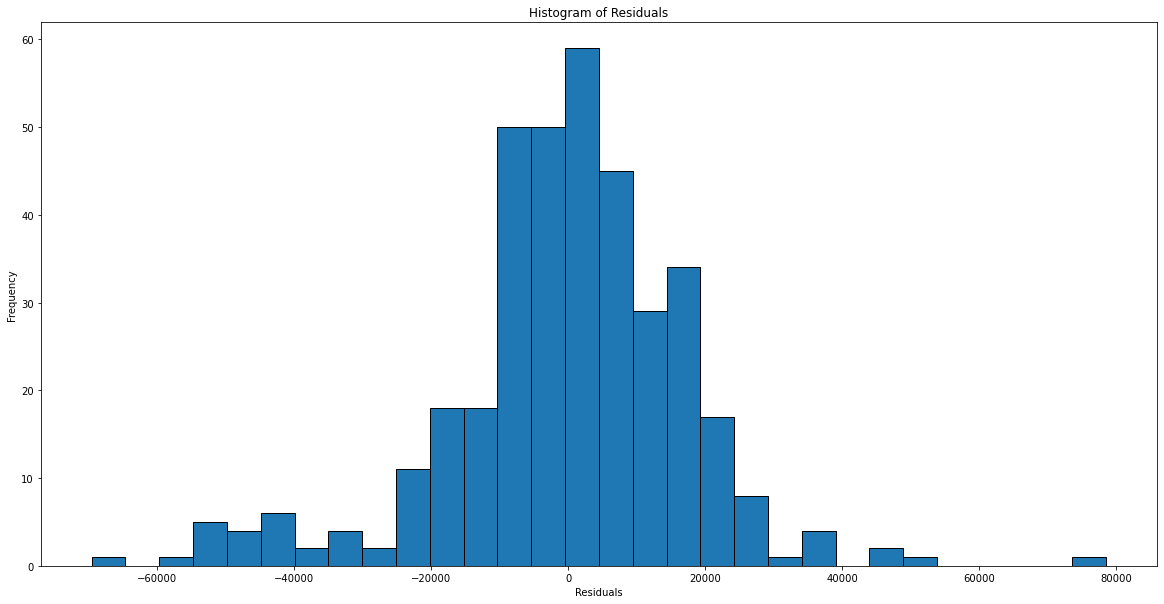

In [49]:
# Print a histogram of the regression model's residuals during training
check_residuals(model_3)

---

### 5. Conclusions and Next Steps

<font color=green> ✅ **Have you done the following?**<br>Drawn detailed and well-considered conclusions from the model?
<br>Explored the limitations of the model and its applicability beyond the data?<br> Fully considered the data question and the hypotheses? <br> Made clear proposals for the organisation and details possible areas for further research? </font>

##### Conclusion

We found that using a linear regression model (OLS) trained on either `Age`, `Years of Experience` or both allows us to predict salaries much better than just considering the mean value of salaries. We also found evidence to reject the null hypothesis in favor of the alternative hypothesis that there is a significant relationship between an individual's salary and their age and years of professional experience (see details in section 4).

Both `Age` and `Years of Experience` were strongly and positively correlated with `Salary` but we found that the relationship between `Salary` and `Age` can largely be attributed to the association of `Age` with `Years of Experience`. Therefore, it is no surprise that we found `Years of experience` to be a better predictor than `Age` and having `Age` as a predictor alongside `Years of experience` did not seem to contribute additional significant explanatory power to our model.

This seems reasonable, as years of experience reflects the time spent in a particular industry or role, building up job-related skills and knowledge, which should be a better indicator of professional abilities and expertise than age. From an ethical standpoint, age can also sometimes be a proxy for perceived capability or potential, which can be misleading or discriminatory. Experience focuses more on professional history and should therefore be more relevant.

##### Limitations and suggestions for further research

We must bare in mind that salary scales can vary significantly across different regions, countries and cultures. A model trained on data from one geographic or cultural context may not perform well in another. The data we got was from a US company and the units were in US dollars. We plan to use this model in the UK, therefore we may wish to collect data from UK companies if we want to put this model into production in the UK.

Through testing some edge cases, we found a limitation that we weren't getting reasonable predictions when predicting outside of the ages our model was trained on (ages 23 - 53). Therefore, we recommend only using this model for ages within this range. The working age in the UK, however, is 16 and retirement age is 66. Therefore, if we want this model to be suitable for all working ages we will need to consider gathering more data from younger and older age groups as future work. Doing so we may no longer see a linear relationship and may need to consider different forms of regression analysis (like polynomial regression or tree-based models).

We also found that the predictions deviate from the actual salary values by around $14,573 on average for our best performing model, trained with `Years of Experience`. This is quite large in the context of salaries and therefore we should consider further work to improve our model before considering deployment. 

The fact that salary changes with age and years of experience does not imply that these cause the change in salary; other factors might be at play (correlation does not equal causation). We recommend as future work to explore other variables that might affect salary like `Job Title` and `Education Level`. This would also allow us to further explore the outliers within certain age groups and certain years of experience, as they may be having an unwanted affect on the model.

---

<font color=green> ✅ **Have you checked the following?**<br>Does the code runs without errors?
<br> Have you used functions rather than duplicating blocks of code? <br> Is the code annotated with comments so that it can be easily read and understood? </font>

---

## The Presentation

You are required to write-up and present your project in such a way that it could be understood by a non-technical colleague.

Slide presentations should be no longer than 10 pages, max. 8 mins long and aimed at a non-technical audience.
    
<font color=green> ✅ **Have you checked the following?**<br>Is the project is well-structured and presented consistently?<br> Does the project have a clear narrative from beginning to end and is comprehensible by a reader without specialist knowledge?<br> Is the text well articulated and engaging? <br> Are the visualizations intelligible and clearly labelled, adding value to the overall analysis and supporting the narrative? </font>



---
<small>© COPYRIGHT 2023 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>